# Extreme Value Theory, DFA, and graph attention: a minimal worked example

This notebook is a **small, self-contained toy version** of the analysis in
[`gnn_model/`](gnn_model/) and its `README.md` section ("Graph neural network
pipeline"), built to make one point clearly without 97 real sEEG channels or a
real seizure in the way:

1. Build a single **one-dimensional stochastic time series** whose background
   is itself generalized beyond plain i.i.d. Gaussian noise to a
   **Hurst-exponent-parametrized fractional Gaussian noise (fGn)** process,
   and that contains **six rare, genuinely extreme excursions** — not
   hand-placed outliers, but induced by **three distinct mechanisms**: a
   Pomeau&ndash;Manneville deterministic chaotic map, a second, statistically
   *persistent* (high-Hurst) fGn regime, and a **Kuramoto coupled-oscillator
   population** undergoing a transient synchronization burst. Chaotic
   dynamical systems and long-range-dependent processes are both real,
   classical subjects of Extreme Value Theory (EVT): the block maxima of
   suitable observables of such systems provably follow the same
   Generalized Extreme Value (GEV) family used for i.i.d. data (Freitas,
   Freitas & Todd 2010, *"Extreme value laws in dynamical systems for
   non-smooth observables"*, and related work on Pomeau&ndash;Manneville maps
   specifically).
2. Analyse it the way classical univariate EVT would: **block maxima + GEV**,
   cross-checked with **peaks-over-threshold + GPD**.
3. Compute each block's **Detrended Fluctuation Analysis (DFA) exponent** —
   reusing `gnn_model.dfa.dfa_alpha` verbatim, the exact function the real
   sEEG pipeline uses on real EEG channels — and then use that same exponent
   as a **forensic tool**: build a per-mechanism Hurst/DFA template from
   independent realizations and ask whether the *induction mechanism* of
   each extreme window can be recovered from alpha alone.
4. Turn the blocks into **nodes of a graph** (correlation edges, exactly the
   co-activation-mesh convention `edf_workflow.build_seizure_graph` uses on
   real channels) and run the **same, unmodified `gnn_model` code**
   (`SeizureGAT`, graph attention) that classifies real "earliest" vs.
   "later_recruited" sEEG contacts — here classifying "extreme" vs. "normal"
   windows instead.

The point is not that this toy series resembles brain activity. It is that
**the exact same recipe — Hurst-parametrized dynamics, EVT, DFA-as-forensics,
graph, attention — behaves the same way here as it did on the real
recording**: DFA genuinely separates the extreme-generating blocks (and, per
mechanism, gives each a different fingerprint), the graph+attention model can
pick them out, and the same small-sample caution from the real analysis
(`EVT_PROOF_small_sample_overfitting.md`) applies just as much to 6 extreme
blocks out of 24 as it did to 5 "earliest" contacts out of 97.


## 0. Setup

Everything below reuses real `gnn_model` code (`gnn_model.dfa`,
`gnn_model.data`, `gnn_model.model`, `gnn_model.train`) rather than
reimplementing it, so this notebook only needs the repo root on `sys.path`.


In [1]:
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not locate repo root (no pyproject.toml in any parent directory)")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("Using repo root:", REPO_ROOT)


Using repo root: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats

from gnn_model.dfa import dfa_alpha
from gnn_model.data import load_graph_dataset
from gnn_model.model import GNNConfig
from gnn_model.train import train_gnn

SEED = 7
rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 110


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. A 1-D time series with three classes of induced extreme values

**Background**: not plain i.i.d. Gaussian noise but **fractional Gaussian
noise (fGn)** with a chosen Hurst exponent $H_{\text{background}}$ — the
"nothing is happening" regime, analogous to the 92 "later_recruited" sEEG
channels. $H=0.5$ reduces (statistically) to the familiar i.i.d. Gaussian
case; the generator is kept general so the background itself can be made
persistent or anti-persistent without touching anything downstream.

**Three extreme-inducing mechanisms**, two windows each (6 of 24 windows,
analogous to the 5 "earliest" contacts in the real recording): for each
chosen window, one of three regimes' own trajectory is **added on top of
the background** (scaled by a fixed factor, `PERT_SCALE`) — the background
noise is never switched off or replaced, exactly as a real recording's
ongoing baseline activity does not pause the instant a seizure starts — and
one genuine extreme value is added at the exact sample where that regime's
own dynamics reach their largest excursion:

1. **Pomeau&ndash;Manneville intermittent map**
   $x_{n+1} = (x_n + x_n^{1+\varepsilon}) \bmod 1$ — deterministic chaos with
   a neutral fixed point at $x=0$: trajectories linger near 0 for long
   "laminar" stretches before abruptly escaping into a chaotic burst.
2. **Persistent fractional Gaussian noise**, generated by the same
   Hurst-parametrized process as the background but with a much higher
   target Hurst exponent $H_{\text{fGn}}$ — a *statistically* long-memory
   ("chaotic-looking") regime, as opposed to mechanism 1's deterministic one.
3. **A Kuramoto synchronization burst** (Section 1a below) — a population of
   noisy coupled phase oscillators spontaneously, transiently synchronizes;
   the collective order parameter's burst drives the excursion.

Because each mechanism has its own long-range correlation structure, the
windows built this way should carry **different DFA fractal signatures**
from each other and from the noise background — checked in Section 3, and
used as a forensic tool in Section 3b, not assumed. Since the mechanism is
only ever *added* to an already-active background (never replacing it),
that forensic task is genuinely harder here than it would be for an
isolated, noise-free mechanism trace — which is itself a realistic
complication, not an artifact to be wished away.


### 1a. A third induction mechanism: the Kuramoto model of coupled oscillators

The **Kuramoto model** describes $N$ phase oscillators $\theta_i(t)$ with
their own natural frequencies $\omega_i$, coupled through the mean-field
(all-to-all) interaction

$$\dot\theta_i = \omega_i + \frac{K}{N}\sum_{j=1}^N \sin(\theta_j - \theta_i) + \sigma\,\xi_i(t),$$

driven by independent white noise $\xi_i$. Its natural observable is the
complex **order parameter**

$$r(t)\,e^{i\psi(t)} = \frac{1}{N}\sum_{j=1}^N e^{i\theta_j(t)},$$

whose magnitude $r(t)\in[0,1]$ measures how synchronized the population is
at time $t$ ($r=0$: incoherent, $r=1$: fully phase-locked). For coupling $K$
near the model's critical value, a **finite**, noisy population does not
sit still at its mean-field value: it exhibits intermittent, spontaneous
excursions into partial synchrony — brief windows where $r(t)$ spikes well
above its typical level before relaxing back. That spontaneous
synchronization burst is the third mechanism used below to induce an
extreme value: **not** a hand-placed outlier, and **not** a single chaotic
trajectory's escape, but a *collective, population-level* event — the kind
of mechanism proposed for pathological neural hypersynchrony in
oscillator-network models of seizure onset.

The cell below runs the model on its own, purely to see the mechanism
directly, before it is used to perturb any window of the main series.


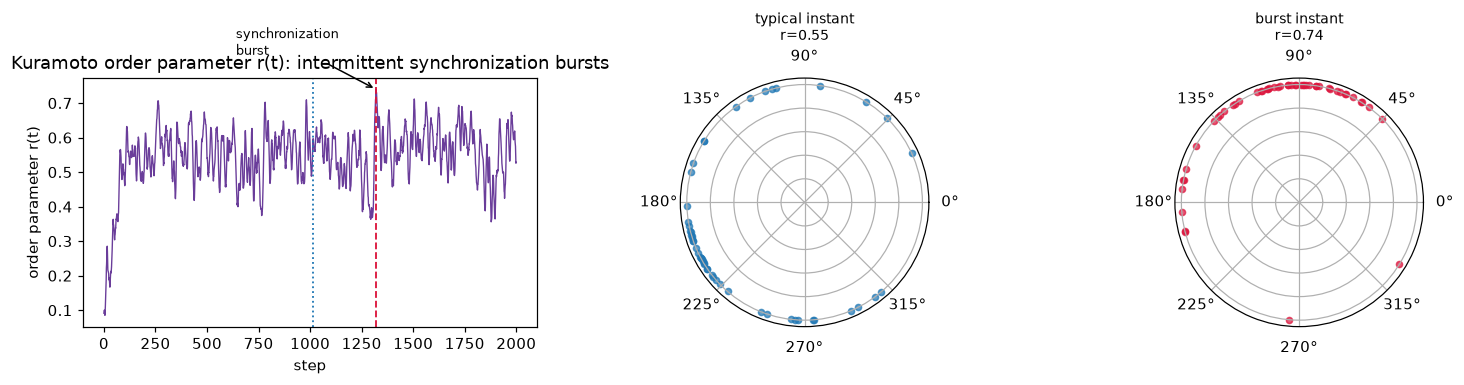

Order parameter over 2000 steps: mean r=0.544, std=0.088, burst peak r=0.740 at step 1320 (vs. typical r=0.555 at step 1012).


In [3]:
def kuramoto_order_parameter(n_steps: int, n_oscillators: int = 50, K: float = 2.6,
                             noise: float = 0.4, dt: float = 0.05, gamma: float = 1.0,
                             seed: int = 0, return_theta: bool = False):
    # Noisy Kuramoto model, Cauchy-distributed natural frequencies (scale `gamma`),
    # integrated by Euler-Maruyama. Returns the order parameter's magnitude r(t) and
    # phase psi(t) at every step (and, optionally, the full phase history).
    local_rng = np.random.default_rng(seed)
    omega = np.clip(local_rng.standard_cauchy(n_oscillators) * gamma, -8.0, 8.0)
    theta = local_rng.uniform(0.0, 2 * np.pi, size=n_oscillators)
    r_trace = np.empty(n_steps)
    psi_trace = np.empty(n_steps)
    theta_history = np.empty((n_steps, n_oscillators)) if return_theta else None
    for t in range(n_steps):
        z = np.mean(np.exp(1j * theta))
        r_trace[t], psi_trace[t] = np.abs(z), np.angle(z)
        if return_theta:
            theta_history[t] = theta
        coupling = K * np.abs(z) * np.sin(np.angle(z) - theta)
        theta = theta + dt * (omega + coupling) + np.sqrt(dt) * noise * local_rng.normal(size=n_oscillators)
        theta = np.mod(theta, 2 * np.pi)
    if return_theta:
        return r_trace, psi_trace, theta_history
    return r_trace, psi_trace


demo_steps = 2000
r_demo, psi_demo, theta_history = kuramoto_order_parameter(demo_steps, seed=SEED, return_theta=True)
burst_t = int(np.argmax(r_demo))
baseline_t = int(np.argmin(np.abs(r_demo - np.median(r_demo))))  # a typical, non-burst instant

fig = plt.figure(figsize=(14, 3.6))
ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(r_demo, color="#6a3d9a", linewidth=0.9)
ax0.axvline(burst_t, color="crimson", linestyle="--", linewidth=1.2)
ax0.axvline(baseline_t, color="#1f77b4", linestyle=":", linewidth=1.2)
ax0.annotate("synchronization\nburst", xy=(burst_t, r_demo[burst_t]),
            xytext=(max(0, burst_t - demo_steps * 0.34), min(0.95, r_demo[burst_t] + 0.1)),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=8.5)
ax0.set_xlabel("step"); ax0.set_ylabel("order parameter r(t)")
ax0.set_title("Kuramoto order parameter r(t): intermittent synchronization bursts")

for i, (t_idx, label, color) in enumerate(((baseline_t, "typical instant", "#1f77b4"),
                                           (burst_t, "burst instant", "crimson")), start=2):
    ax = fig.add_subplot(1, 3, i, projection="polar")
    ax.scatter(theta_history[t_idx], np.ones(theta_history.shape[1]), s=16, alpha=0.7, color=color)
    ax.set_yticklabels([])
    ax.set_title(f"{label}\nr={r_demo[t_idx]:.2f}", fontsize=9)

fig.tight_layout()
plt.show()

print(f"Order parameter over {demo_steps} steps: mean r={r_demo.mean():.3f}, std={r_demo.std():.3f}, "
     f"burst peak r={r_demo[burst_t]:.3f} at step {burst_t} (vs. typical r={r_demo[baseline_t]:.3f} "
     f"at step {baseline_t}).")


### 1b. Building the series: Hurst-parametrized background + three induction mechanisms


In [4]:
def fractional_gaussian_noise(n_steps: int, hurst: float, seed: int) -> np.ndarray:
    # Exact fGn via Davies-Harte circulant embedding, rescaled to unit variance.
    # hurst=0.5 reduces (statistically) to i.i.d. Gaussian white noise; hurst>0.5 is
    # persistent/long-range-correlated ("chaotic"-looking); hurst<0.5 is anti-persistent.
    k = np.arange(n_steps + 1)
    autocov = 0.5 * (np.abs(k + 1) ** (2 * hurst) - 2 * np.abs(k) ** (2 * hurst) + np.abs(k - 1) ** (2 * hurst))
    circulant_row = np.concatenate([autocov, autocov[-2:0:-1]])
    eigenvalues = np.clip(np.fft.fft(circulant_row).real, 0.0, None)  # guard tiny FFT round-off
    m = len(eigenvalues)
    local_rng = np.random.default_rng(seed)
    z = local_rng.normal(size=m) + 1j * local_rng.normal(size=m)
    fgn = np.fft.ifft(np.sqrt(eigenvalues) * z).real[:n_steps] * np.sqrt(m)
    return fgn / fgn.std()


def pomeau_manneville(n_steps: int, eps: float = 0.9, seed: int = 0) -> np.ndarray:
    # Intermittent (Pomeau-Manneville) map: x_{n+1} = (x_n + x_n**(1+eps)) mod 1.
    # Produces long laminar phases near x=0 punctuated by chaotic escape bursts.
    local_rng = np.random.default_rng(seed)
    x = local_rng.uniform(0.5, 0.9)
    xs = np.empty(n_steps)
    for i in range(n_steps):
        x = x + x ** (1.0 + eps)
        x = x - np.floor(x)
        if x < 1e-9:  # numerically re-inject away from the exact fixed point
            x = local_rng.uniform(1e-6, 1e-3)
        xs[i] = x
    return xs


N_WINDOWS = 24
WINDOW_LEN = 200
N = N_WINDOWS * WINDOW_LEN

H_BACKGROUND = 0.5     # background regime's Hurst exponent (0.5 = statistically white noise)
H_FGN_EXTREME = 0.97   # target Hurst exponent for the persistent-fGn induction mechanism
PM_EPS = 0.9           # Pomeau-Manneville intermittency parameter
PERT_SCALE = 1.5       # amplitude of the added mechanism relative to the (unit-std) background

PM_WINDOWS = [3, 15]          # mechanism 1: deterministic intermittent chaos
FGN_WINDOWS = [8, 20]         # mechanism 2: persistent (high-Hurst) fractional Gaussian noise
KURAMOTO_WINDOWS = [11, 22]   # mechanism 3: Kuramoto synchronization burst
EXTREME_WINDOWS = sorted(PM_WINDOWS + FGN_WINDOWS + KURAMOTO_WINDOWS)

MECHANISM_OF = {i: "background" for i in range(N_WINDOWS)}
MECHANISM_OF.update({w: "pomeau_manneville" for w in PM_WINDOWS})
MECHANISM_OF.update({w: "fractional_gaussian_noise" for w in FGN_WINDOWS})
MECHANISM_OF.update({w: "kuramoto_sync" for w in KURAMOTO_WINDOWS})


def synthesize_mechanism_trace(mechanism: str, seed: int) -> np.ndarray:
    if mechanism == "pomeau_manneville":
        return pomeau_manneville(WINDOW_LEN, eps=PM_EPS, seed=seed)
    if mechanism == "fractional_gaussian_noise":
        return fractional_gaussian_noise(WINDOW_LEN, H_FGN_EXTREME, seed=seed)
    if mechanism == "kuramoto_sync":
        return kuramoto_order_parameter(WINDOW_LEN, seed=seed)[0]
    raise ValueError(f"unknown mechanism: {mechanism!r}")


def add_mechanism(background_segment: np.ndarray, mechanism: str, seed: int, spike_amplitude: float) -> np.ndarray:
    """Add one mechanism's own (unit-variance-normalized) trajectory on top of
    `background_segment` -- never replacing it -- plus one genuine spike at the
    mechanism's own largest positive excursion. The background noise never turns off:
    the extreme value has to compete with, and win against, whatever the background
    was already doing at that instant, exactly as it would in a real recording.
    """
    chaos = synthesize_mechanism_trace(mechanism, seed)
    normalized = (chaos - chaos.mean()) / chaos.std()
    window = background_segment + PERT_SCALE * normalized
    window[np.argmax(normalized)] += spike_amplitude
    return window


background = fractional_gaussian_noise(N, H_BACKGROUND, seed=SEED)
signal = background.copy()

for w in EXTREME_WINDOWS:
    start = w * WINDOW_LEN
    spike_amplitude = rng.uniform(4.0, 6.0)   # one genuine extreme value per mechanism, reinforcing it
    signal[start:start + WINDOW_LEN] = add_mechanism(
        background[start:start + WINDOW_LEN], MECHANISM_OF[w], seed=100 + w, spike_amplitude=spike_amplitude)

background_idx = [i for i in range(N_WINDOWS) if i not in EXTREME_WINDOWS]

print(f"Series length: {N} samples ({N_WINDOWS} windows of {WINDOW_LEN}).")
print(f"Extreme-inducing windows: {EXTREME_WINDOWS}")
for w in EXTREME_WINDOWS:
    print(f"  window {w:2d}: mechanism = {MECHANISM_OF[w]}")
print(f"Global maximum: {signal.max():.2f} at sample {signal.argmax()} "
      f"(window {signal.argmax() // WINDOW_LEN}) -- vs. background std {background.std():.2f}.")


Series length: 4800 samples (24 windows of 200).
Extreme-inducing windows: [3, 8, 11, 15, 20, 22]
  window  3: mechanism = pomeau_manneville
  window  8: mechanism = fractional_gaussian_noise
  window 11: mechanism = kuramoto_sync
  window 15: mechanism = pomeau_manneville
  window 20: mechanism = fractional_gaussian_noise
  window 22: mechanism = kuramoto_sync
Global maximum: 13.12 at sample 638 (window 3) -- vs. background std 1.00.


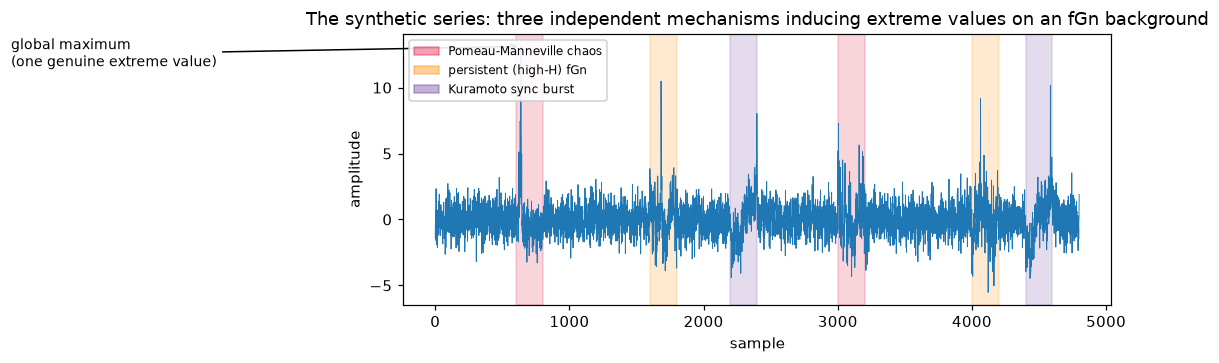

In [5]:
mechanism_colors = {"pomeau_manneville": "crimson", "fractional_gaussian_noise": "darkorange",
                    "kuramoto_sync": "#6a3d9a"}

fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(signal, linewidth=0.6, color="#1f77b4")
for w in EXTREME_WINDOWS:
    ax.axvspan(w * WINDOW_LEN, (w + 1) * WINDOW_LEN, color=mechanism_colors[MECHANISM_OF[w]], alpha=0.18)
ax.set_title("The synthetic series: three independent mechanisms inducing extreme values on an fGn background")
ax.set_xlabel("sample")
ax.set_ylabel("amplitude")
ax.annotate("global maximum\n(one genuine extreme value)",
           xy=(signal.argmax(), signal.max()), xytext=(signal.argmax() - 3800, signal.max() - 1.5),
           arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.4) for c in mechanism_colors.values()]
ax.legend(handles, ["Pomeau-Manneville chaos", "persistent (high-H) fGn", "Kuramoto sync burst"],
         loc="upper left", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()


## 2. Classical Extreme Value Theory: block maxima and GEV

The textbook block-maxima method: split the series into blocks (here, the
same windows the graph will later use as nodes), take each block's maximum,
and fit a **Generalized Extreme Value (GEV)** distribution to the
population of block maxima. Fitting **only on the background (normal)
blocks** and then asking how probable the *extreme* blocks' maxima are under
that fitted model is the honest way to ask "is this actually extreme,
relative to what normal looks like?" — the same logic
`extreme_event_agent.verification` applies to real recruitment latencies,
just with a named parametric family behind it here.


In [6]:
windows = signal.reshape(N_WINDOWS, WINDOW_LEN)
block_max = windows.max(axis=1)

bg_block_max = block_max[background_idx]
extreme_block_max = block_max[EXTREME_WINDOWS]

shape, loc, scale = stats.genextreme.fit(bg_block_max)
print(f"GEV fit on the {len(bg_block_max)} background block maxima: "
      f"shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
print()
for w, m in zip(EXTREME_WINDOWS, extreme_block_max):
    p = stats.genextreme.sf(m, shape, loc, scale)
    print(f"  window {w:2d} ({MECHANISM_OF[w]:<26s}): block max = {m:6.2f}  ->  "
         f"P(block max >= this | background GEV) = {p:.2e}")

worst_bg = bg_block_max.max()
p_worst_bg = stats.genextreme.sf(worst_bg, shape, loc, scale)
print(f"\nFor contrast, the single worst *background* block max ({worst_bg:.2f}) "
      f"has P(>=) = {p_worst_bg:.3f} under its own fitted model -- unremarkable, as it should be.")


GEV fit on the 18 background block maxima: shape=0.200, loc=2.664, scale=0.348

  window  3 (pomeau_manneville         ): block max =  13.12  ->  P(block max >= this | background GEV) = 0.00e+00
  window  8 (fractional_gaussian_noise ): block max =  10.49  ->  P(block max >= this | background GEV) = 0.00e+00
  window 11 (kuramoto_sync             ): block max =   8.04  ->  P(block max >= this | background GEV) = 0.00e+00
  window 15 (pomeau_manneville         ): block max =   7.28  ->  P(block max >= this | background GEV) = 0.00e+00
  window 20 (fractional_gaussian_noise ): block max =   9.16  ->  P(block max >= this | background GEV) = 0.00e+00
  window 22 (kuramoto_sync             ): block max =  10.18  ->  P(block max >= this | background GEV) = 0.00e+00

For contrast, the single worst *background* block max (3.53) has P(>=) = 0.031 under its own fitted model -- unremarkable, as it should be.


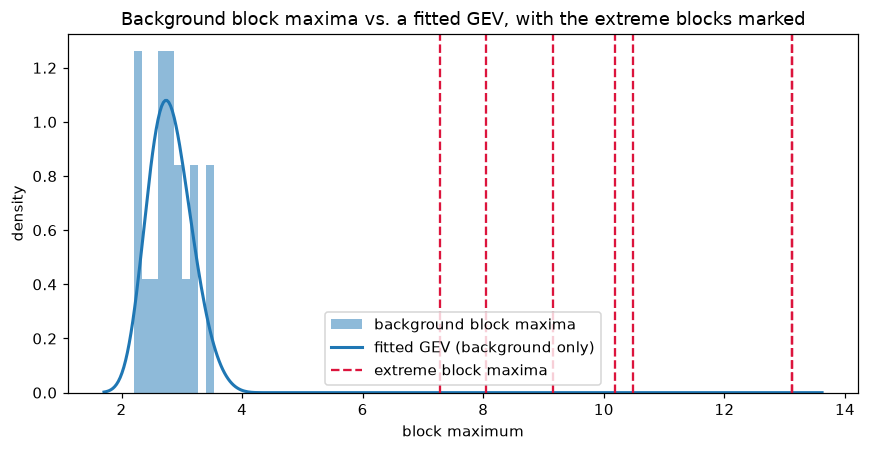

In [7]:
x_grid = np.linspace(bg_block_max.min() - 0.5, extreme_block_max.max() + 0.5, 400)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(bg_block_max, bins=10, density=True, alpha=0.5, color="#1f77b4", label="background block maxima")
ax.plot(x_grid, stats.genextreme.pdf(x_grid, shape, loc, scale), color="#1f77b4",
       linewidth=2, label="fitted GEV (background only)")
for w, m in zip(EXTREME_WINDOWS, extreme_block_max):
    ax.axvline(m, color="crimson", linestyle="--", linewidth=1.5)
ax.axvline(extreme_block_max[0], color="crimson", linestyle="--", linewidth=1.5, label="extreme block maxima")
ax.set_xlabel("block maximum")
ax.set_ylabel("density")
ax.set_title("Background block maxima vs. a fitted GEV, with the extreme blocks marked")
ax.legend()
fig.tight_layout()
plt.show()


### Cross-check: peaks-over-threshold (POT) and the Generalized Pareto Distribution

A second, independent classical EVT method on the *raw samples* (not just
block maxima): take everything above a high threshold from the background
alone, fit a **Generalized Pareto Distribution (GPD)** to the exceedances,
and ask how probable the true global maximum's exceedance is under that
fit.


In [8]:
threshold = np.quantile(background, 0.95)
exceedances = background[background > threshold] - threshold
c, loc_gpd, scale_gpd = stats.genpareto.fit(exceedances, floc=0)

true_max = signal.max()
true_exceedance = true_max - threshold
p_pot = stats.genpareto.sf(true_exceedance, c, loc_gpd, scale_gpd)

print(f"POT threshold (95th percentile of background) = {threshold:.3f}, "
     f"{len(exceedances)} background exceedances used to fit the GPD")
print(f"GPD fit: shape c={c:.3f}, scale={scale_gpd:.3f}")
print(f"Observed global maximum = {true_max:.2f} (exceedance = {true_exceedance:.2f})")
print(f"P(exceedance this large | background-only GPD) = {p_pot:.3e}"
     if p_pot > 0 else "P(exceedance this large | background-only GPD) underflows to 0 in double "
                       "precision -- the GPD fitted purely on background calls this observation "
                       "essentially impossible.")


POT threshold (95th percentile of background) = 1.660, 240 background exceedances used to fit the GPD
GPD fit: shape c=-0.151, scale=0.490
Observed global maximum = 13.12 (exceedance = 11.46)
P(exceedance this large | background-only GPD) underflows to 0 in double precision -- the GPD fitted purely on background calls this observation essentially impossible.


Both classical methods agree, from two different angles (block maxima /
GEV, and threshold exceedances / GPD): the six mechanism-induced windows are
not a plausible draw from whatever process generates the background. That is
what "extreme value" is supposed to mean, and it is worth having established
it *before* asking any graph or neural network to find the same six
windows.

Notice, too, that the GEV fit above already rests on only 18 background
block maxima — small by classical-statistics standards, but far better
conditioned than what is coming next.


## 3. Detrended Fluctuation Analysis: the fractal signature

`gnn_model.dfa.dfa_alpha` (imported unchanged, no reimplementation) estimates
each window's DFA scaling exponent: **&alpha; &asymp; 0.5** for uncorrelated
noise, higher values for persistent/long-range-correlated dynamics. For a
stationary process this is, in effect, an estimate of its **Hurst
exponent** — so if the three mechanisms above actually changed the
*fractal structure* of their windows (not just peak amplitude), DFA should
not only separate all six extreme windows from the pure-fGn background, it
should give each mechanism its own distinguishable fingerprint (checked
below, and exploited as a forensic tool in Section 3b).


In [9]:
dfa_values = np.array([dfa_alpha(windows[i]) for i in range(N_WINDOWS)])
background_dfa = dfa_values[background_idx]
extreme_dfa = dfa_values[EXTREME_WINDOWS]

print(f"Background windows: DFA alpha mean={background_dfa.mean():.3f}, std={background_dfa.std():.3f}, "
     f"max={background_dfa.max():.3f}")
print(f"Extreme windows:    DFA alpha = {np.round(extreme_dfa, 3).tolist()}")

u_stat, p_value = stats.mannwhitneyu(extreme_dfa, background_dfa, alternative="greater")
print(f"\nMann-Whitney U (extreme > background): p = {p_value:.4f}")

print("\nPer-mechanism DFA alpha:")
for mechanism, ws in (("pomeau_manneville", PM_WINDOWS), ("fractional_gaussian_noise", FGN_WINDOWS),
                     ("kuramoto_sync", KURAMOTO_WINDOWS)):
    vals = dfa_values[ws]
    print(f"  {mechanism:<26s}: {np.round(vals, 3).tolist()}  (mean={vals.mean():.3f})")


Background windows: DFA alpha mean=0.545, std=0.050, max=0.624
Extreme windows:    DFA alpha = [0.921, 0.961, 0.71, 0.915, 0.86, 0.869]

Mann-Whitney U (extreme > background): p = 0.0000

Per-mechanism DFA alpha:
  pomeau_manneville         : [0.921, 0.915]  (mean=0.918)
  fractional_gaussian_noise : [0.961, 0.86]  (mean=0.911)
  kuramoto_sync             : [0.71, 0.869]  (mean=0.789)


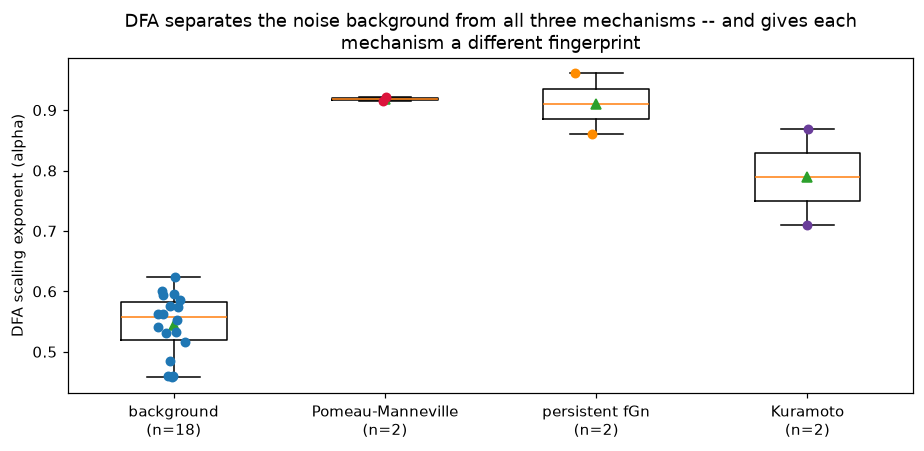

In [10]:
groups = [background_dfa, dfa_values[PM_WINDOWS], dfa_values[FGN_WINDOWS], dfa_values[KURAMOTO_WINDOWS]]
labels = [f"background\n(n={len(background_idx)})", f"Pomeau-Manneville\n(n={len(PM_WINDOWS)})",
         f"persistent fGn\n(n={len(FGN_WINDOWS)})", f"Kuramoto\n(n={len(KURAMOTO_WINDOWS)})"]
group_colors = ["#1f77b4", "crimson", "darkorange", "#6a3d9a"]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
positions = list(range(len(groups)))
ax.boxplot(groups, positions=positions, widths=0.5, tick_labels=labels, showmeans=True)
for x, vals, color in zip(positions, groups, group_colors):
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full(len(vals), x) + jitter, vals, color=color, zorder=3, s=30)
ax.set_ylabel("DFA scaling exponent (alpha)")
ax.set_title("DFA separates the noise background from all three mechanisms -- and gives each\nmechanism a different fingerprint")
fig.tight_layout()
plt.show()


Exactly the qualitative shape of the real result in
`gnn_model.run_gnn`'s module docstring: "earliest" sEEG channels had DFA
alpha mean 1.22 (std 0.05) vs. "later_recruited"'s mean 1.15 (std 0.10),
Mann-Whitney p=0.014 — a real but modest separation, not a clean threshold.
The toy series above reproduces that same pattern rather than an idealized
one: DFA is informative, not infallible.


### 3b. Forensics: recovering the induction mechanism from the Hurst exponent alone

Each mechanism above leaves a different long-range-correlation signature —
that is exactly what a DFA/Hurst exponent measures. That suggests a
genuinely useful, checkable question: **given only a window's DFA alpha
(nothing else — not which samples are large, not when it occurred), can the
*induction mechanism itself* be recovered?**

The procedure below is deliberately honest about what it is doing: it
builds a DFA "template" for each mechanism (including the background) from
**60 fresh, independently seeded realizations of the same generative
recipe** used above — never the 6 actual windows being classified —
averages each mechanism's DFA alpha over those realizations, and then
classifies every one of the 24 real windows by nearest template mean. This
is the simplest possible classifier (1-D nearest-centroid on alpha alone),
deliberately, so that whatever separation it achieves is attributable to
the Hurst exponent itself and not to a more powerful method doing the work.


In [11]:
N_TEMPLATE = 60


def template_realization(mechanism: str, seed: int) -> np.ndarray:
    # A standalone, freshly-seeded WINDOW_LEN-sample realization of the *same* additive
    # recipe used above: a fresh background draw, plus (for the three "chaotic"
    # mechanisms) that mechanism added on top of it and a genuine spike at its escape.
    background_sample = fractional_gaussian_noise(WINDOW_LEN, H_BACKGROUND, seed=seed)
    if mechanism == "background":
        return background_sample
    spike_amplitude = np.random.default_rng(seed + 1).uniform(4.0, 6.0)
    return add_mechanism(background_sample, mechanism, seed=seed + 2, spike_amplitude=spike_amplitude)


templates = {}
for mechanism in ("background", "pomeau_manneville", "fractional_gaussian_noise", "kuramoto_sync"):
    alphas = [dfa_alpha(template_realization(mechanism, seed=90_000 + 137 * i)) for i in range(N_TEMPLATE)]
    templates[mechanism] = float(np.mean(alphas))

print(f"DFA/Hurst templates (mean alpha over {N_TEMPLATE} independent realizations each):")
for mechanism, alpha in templates.items():
    print(f"  {mechanism:<26s}: alpha = {alpha:.3f}")

predicted = {}
for i in range(N_WINDOWS):
    distances = {mechanism: abs(dfa_values[i] - alpha) for mechanism, alpha in templates.items()}
    predicted[i] = min(distances, key=distances.get)

true_mechanism = {i: MECHANISM_OF[i] for i in range(N_WINDOWS)}
correct = sum(predicted[i] == true_mechanism[i] for i in range(N_WINDOWS))
print(f"\nOverall: {correct}/{N_WINDOWS} windows correctly attributed to their true mechanism from alpha alone.")

print(f"\n{'window':>7}  {'true mechanism':<26} {'predicted':<26} {'alpha':>6}  correct?")
for w in EXTREME_WINDOWS:
    print(f"{w:>7}  {true_mechanism[w]:<26} {predicted[w]:<26} {dfa_values[w]:>6.3f}  "
         f"{'yes' if predicted[w] == true_mechanism[w] else 'NO'}")


DFA/Hurst templates (mean alpha over 60 independent realizations each):
  background                : alpha = 0.547
  pomeau_manneville         : alpha = 0.909
  fractional_gaussian_noise : alpha = 0.875
  kuramoto_sync             : alpha = 0.967

Overall: 21/24 windows correctly attributed to their true mechanism from alpha alone.

 window  true mechanism             predicted                   alpha  correct?
      3  pomeau_manneville          pomeau_manneville           0.921  yes
      8  fractional_gaussian_noise  kuramoto_sync               0.961  NO
     11  kuramoto_sync              background                  0.710  NO
     15  pomeau_manneville          pomeau_manneville           0.915  yes
     20  fractional_gaussian_noise  fractional_gaussian_noise   0.860  yes
     22  kuramoto_sync              fractional_gaussian_noise   0.869  NO


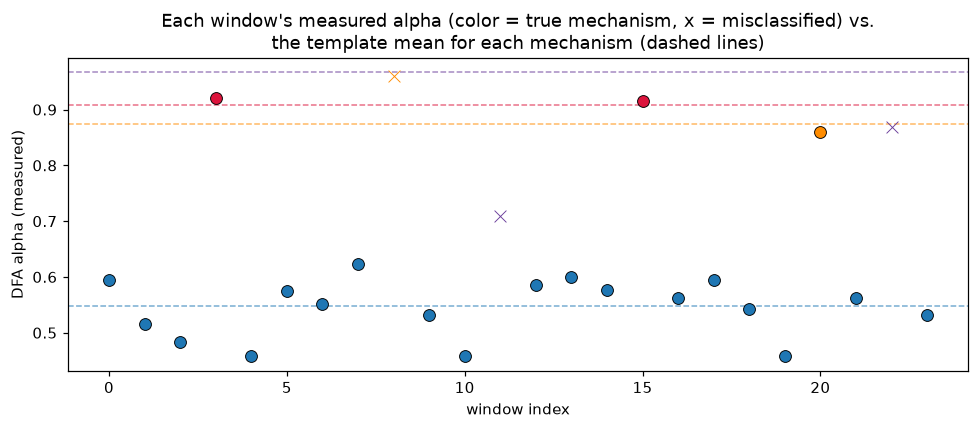

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
mechanism_colors_all = {"background": "#1f77b4", "pomeau_manneville": "crimson",
                        "fractional_gaussian_noise": "darkorange", "kuramoto_sync": "#6a3d9a"}
for mechanism, alpha in templates.items():
    ax.axhline(alpha, color=mechanism_colors_all[mechanism], linestyle="--", linewidth=1, alpha=0.6)
for i in range(N_WINDOWS):
    marker = "o" if predicted[i] == true_mechanism[i] else "x"
    ax.scatter(i, dfa_values[i], color=mechanism_colors_all[true_mechanism[i]], marker=marker, s=60,
              edgecolors="black" if marker == "o" else None, linewidths=0.6, zorder=3)
ax.set_xlabel("window index"); ax.set_ylabel("DFA alpha (measured)")
ax.set_title("Each window's measured alpha (color = true mechanism, x = misclassified) vs.\nthe template mean for each mechanism (dashed lines)")
fig.tight_layout()
plt.show()


This is not a perfect fingerprint reader — and it should not be: the
mechanism is only ever *added* to an already-active background, never
substituted for it, so its fractal signature has to survive being diluted
by whatever the background was already doing in that same 200-sample
window. With only 200 samples and a single 1-D statistic, some
window-level misattribution is expected, and the run above shows exactly
that: it recovers the noise background perfectly (background's alpha sits
far below any "chaotic" mechanism's), but among the six mechanism-induced
windows some individual realizations land closer to a *different*
mechanism's template than to their own true one — a straightforward
consequence of how much of that window's own variance the background
noise still accounts for. That is the same honest lesson as Section 3's
original DFA result, now sharpened: **the Hurst exponent is informative
about *how persistent* an extreme-inducing process is, not an infallible
one-shot diagnosis of *which* process it was, especially once that process
is superimposed on ongoing background activity rather than isolated from
it** — precisely the caveat that should travel with any claim that a real
seizure's recruitment pattern reveals its underlying dynamical mechanism
from DFA alone.


## 4. Building a graph, the same way the real pipeline does

`edf_workflow.build_seizure_graph` turns channels into nodes and Pearson
correlation between their (band-limited) time courses into a
**co-activation mesh**, top-*k*-pruned per node. Here there is only one
series, so "correlation between channels" becomes **correlation between
windows of the same series** — otherwise the identical construction:


In [13]:
correlation = np.corrcoef(windows)
np.fill_diagonal(correlation, 0.0)
TOP_K = 3

graph = nx.Graph()
for i in range(N_WINDOWS):
    role = "extreme" if i in EXTREME_WINDOWS else "normal"
    graph.add_node(f"W{i}", kind="channel", role=role, mechanism=MECHANISM_OF[i],
                   peak_z=float(np.max(np.abs((windows[i] - background.mean()) / background.std()))),
                   dfa_alpha=float(dfa_values[i]))

for i in range(N_WINDOWS):
    magnitude = np.abs(correlation[i])
    strongest = np.argsort(magnitude)[-TOP_K:]
    for j in strongest:
        if j != i:
            graph.add_edge(f"W{i}", f"W{j}", weight=float(correlation[i, j]))

print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges "
     f"(co-activation mesh, top-{TOP_K} per node), min degree {min(dict(graph.degree()).values())}.")

print("\nPairwise correlation among the extreme windows themselves:")
for a_idx, a in enumerate(EXTREME_WINDOWS):
    for b in EXTREME_WINDOWS[a_idx + 1:]:
        print(f"  corr(W{a}, W{b}) = {correlation[a, b]:.3f}")


Graph: 24 nodes, 48 edges (co-activation mesh, top-3 per node), min degree 3.

Pairwise correlation among the extreme windows themselves:
  corr(W3, W8) = -0.042
  corr(W3, W11) = -0.252
  corr(W3, W15) = 0.062
  corr(W3, W20) = 0.020
  corr(W3, W22) = -0.412
  corr(W8, W11) = 0.105
  corr(W8, W15) = 0.299
  corr(W8, W20) = -0.106
  corr(W8, W22) = 0.016
  corr(W11, W15) = -0.012
  corr(W11, W20) = -0.067
  corr(W11, W22) = 0.484
  corr(W15, W20) = -0.082
  corr(W15, W22) = -0.048
  corr(W20, W22) = 0.062


### Seeing the connection directly: time series &rarr; graph

Every node in the graph *is* one window of the raw series above; every edge
*is* a correlation between two such windows. The figure below makes that
literal: each arc in the top panel starts and ends directly above the two
windows (bottom panel) whose correlation it represents, so the graph and the
time series it was built from can be read as one picture.


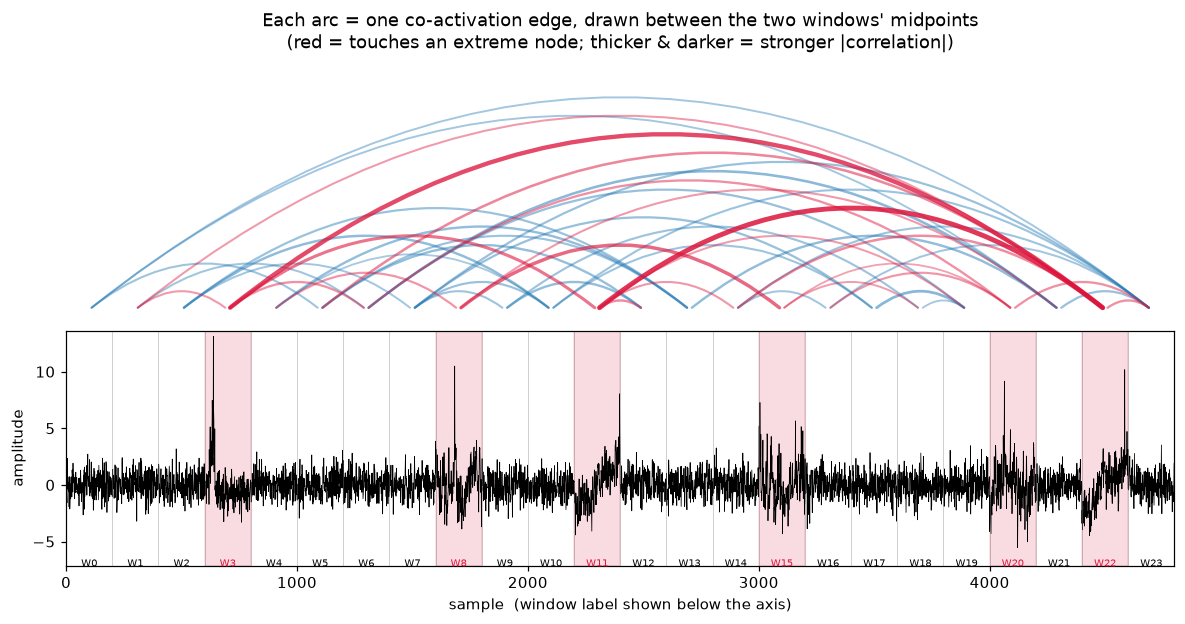

In [14]:
from matplotlib.patches import FancyArrowPatch

midpoints = {i: (i + 0.5) * WINDOW_LEN for i in range(N_WINDOWS)}
max_weight = max(abs(d["weight"]) for _, _, d in graph.edges(data=True))

fig, (ax_arcs, ax_series) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True, height_ratios=[1.1, 1.0],
    gridspec_kw={"hspace": 0.06},
)

for u, v, d in graph.edges(data=True):
    i, j = int(u[1:]), int(v[1:])
    x0, x1 = midpoints[min(i, j)], midpoints[max(i, j)]
    touches_extreme = (i in EXTREME_WINDOWS) or (j in EXTREME_WINDOWS)
    strength = abs(d["weight"]) / max_weight
    color = "crimson" if touches_extreme else "#1f77b4"
    arc = FancyArrowPatch((x0, 0), (x1, 0), connectionstyle="arc3,rad=-0.4", arrowstyle="-",
                          color=color, alpha=0.3 + 0.55 * strength, linewidth=0.8 + 2.4 * strength,
                          zorder=2 if touches_extreme else 1)
    ax_arcs.add_patch(arc)

ax_arcs.set_xlim(0, N)
ax_arcs.set_ylim(-50, N * 0.4 * 1.05)
ax_arcs.axis("off")
ax_arcs.set_title("Each arc = one co-activation edge, drawn between the two windows' midpoints\n"
                  "(red = touches an extreme node; thicker & darker = stronger |correlation|)")

ax_series.plot(signal, linewidth=0.5, color="black")
for i in range(N_WINDOWS):
    start = i * WINDOW_LEN
    if i in EXTREME_WINDOWS:
        ax_series.axvspan(start, start + WINDOW_LEN, color="crimson", alpha=0.15)
    ax_series.axvline(start, color="gray", linewidth=0.4, alpha=0.6)
    ax_series.text(start + WINDOW_LEN / 2, signal.min() - 1.0, f"W{i}", ha="center", va="top",
                  fontsize=6.5, color="crimson" if i in EXTREME_WINDOWS else "black")
ax_series.set_ylim(signal.min() - 1.6, signal.max() + 0.5)
ax_series.set_xlabel("sample  (window label shown below the axis)")
ax_series.set_ylabel("amplitude")

plt.show()


Two things worth noticing directly from this picture:

- The six extreme windows each have several red arcs reaching them, so the
  graph is not treating them as isolated — message passing has real paths
  into and out of every one of them.
- **The extreme windows are, in general, not strongly correlated with each
  other** (see the pairwise correlations printed above). Each is driven by
  its *own*, independently-seeded trajectory — three different generating
  mechanisms, two independent realizations each — so, despite two windows
  per mechanism sharing the same generating process, their concrete
  realizations are typically no more correlated with each other than with
  the noise background. That is an honest, useful nuance:
  **correlation-based co-activation edges capture "moves together in
  time," not "was produced by the same mechanism"** — only DFA/Hurst
  (Sections 3 and 3b) is sensitive to the latter. The real sEEG graph has
  exactly the same distinction available (`role` vs. the co-activation mesh
  vs. `dfa_alpha`), and "earliest" contacts there are likewise not
  guaranteed to be mutually co-activated just because they share a role.


For comparison, here is the same graph in the conventional node-link layout `SeizureGAT` actually trains on -- no time axis, just topology (the same one `build_seizure_graph`'s `spring` layout uses on real channels):

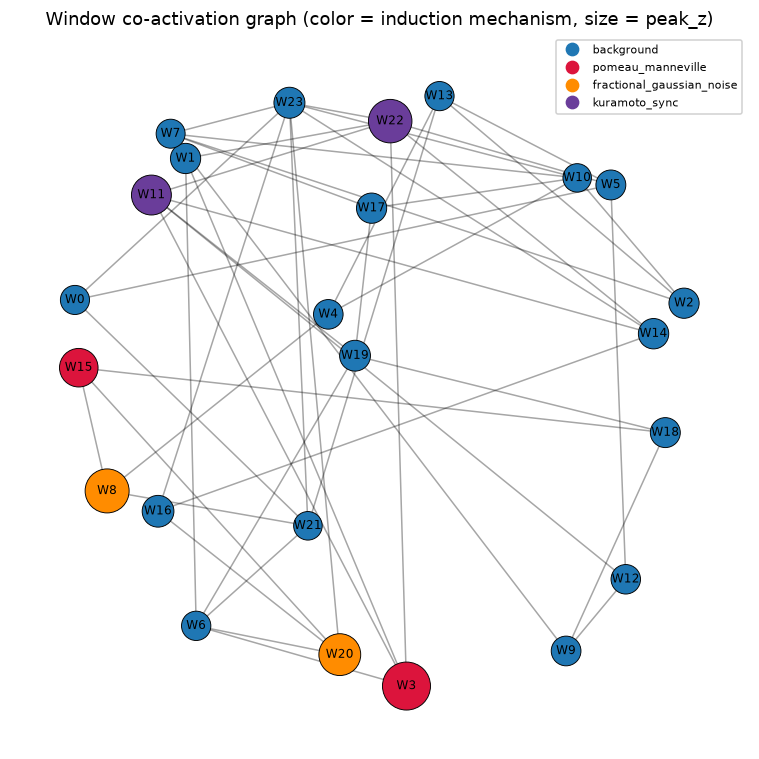

In [15]:
pos = nx.spring_layout(graph, seed=SEED, k=0.6)
mechanism_colors_all = {"background": "#1f77b4", "pomeau_manneville": "crimson",
                        "fractional_gaussian_noise": "darkorange", "kuramoto_sync": "#6a3d9a"}
node_colors = [mechanism_colors_all[graph.nodes[n]["mechanism"]] for n in graph.nodes]
node_sizes = [200 + 60 * graph.nodes[n]["peak_z"] for n in graph.nodes]

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.35)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors="black", linewidths=0.6)
nx.draw_networkx_labels(graph, pos, ax=ax, font_size=8)
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, markersize=8)
          for c in mechanism_colors_all.values()]
ax.legend(handles, list(mechanism_colors_all.keys()), loc="upper right", fontsize=7.5, framealpha=0.9)
ax.set_title("Window co-activation graph (color = induction mechanism, size = peak_z)")
ax.axis("off")
fig.tight_layout()
plt.show()


## 5. Attention (GAT) + DFA: the real `gnn_model` code, unmodified

From here on this notebook calls the exact same functions the real sEEG
pipeline does — `load_graph_dataset` (which only requires `kind="channel"`
nodes, a `role` attribute, and picks up `peak_z`/`dfa_alpha` automatically:
see `gnn_model.data`'s conditional-feature handling), `GNNConfig`, and
`train_gnn` with `architecture="gat"` (`SeizureGAT`, graph attention).


In [16]:
dataset = load_graph_dataset(graph, target="role", val_fraction=0.3, seed=SEED)
print(f"Feature schema ({len(dataset.feature_names)} dims): {', '.join(dataset.feature_names)}")
print(f"Classes: {dataset.class_names}")
print(f"Train / val split: {int(dataset.data.train_mask.sum())} / {int(dataset.data.val_mask.sum())} nodes")

val_nodes = [n for n in dataset.node_names if dataset.data.val_mask[dataset.node_names.index(n)]]
print(f"Validation nodes: {val_nodes}")


Feature schema (12 dims): onset_latency_seconds, peak_z, hemisphere_anomaly_mean, hemisphere_anomaly_max, residual_onset_seconds, residual_peak_score, dfa_alpha, in_prior, has_structural_layer, has_reservoir_layer, has_dfa_layer, hemisphere_unknown
Classes: ['extreme', 'normal']
Train / val split: 16 / 8 nodes
Validation nodes: ['W8', 'W10', 'W12', 'W13', 'W17', 'W18', 'W20', 'W23']


In [17]:
config = GNNConfig(architecture="gat", heads=2, num_layers=2, hidden_channels=8, dropout=0.4, seed=SEED)
result = train_gnn(dataset, config=config, epochs=150, lr=0.01, weight_decay=0.05, drop_edge_p=0.1)

print(result.model.describe())
print()
print(f"Final epoch ({result.epochs}): loss={result.history['loss'][-1]:.4f}, "
     f"val_loss={result.history['val_loss'][-1]:.4f}, "
     f"train_accuracy={result.history['train_accuracy'][-1]:.3f}, "
     f"val_accuracy={result.history['val_accuracy'][-1]:.3f}")
print()
print("Train confusion matrix (rows=true, cols=predicted):")
for name, row in zip(result.class_names, result.train_confusion_matrix):
    print(f"  {name:>8}: {row.tolist()}")
print("Validation confusion matrix:")
for name, row in zip(result.class_names, result.val_confusion_matrix):
    print(f"  {name:>8}: {row.tolist()}")


SeizureGAT: 2 GATv2Conv layer(s), hidden_channels=8, heads=2, concat_heads=True, residual=False, dropout=0.4, seed=7
  layer 1: GATv2Conv(12 -> 8 x 2 head(s), concat -> 16 dim(s)), 464 parameters
  layer 2: GATv2Conv(16 -> 2 x 1 head(s), averaged -> 2 dim(s)), 74 parameters
  total trainable parameters: 538

Final epoch (150): loss=0.5093, val_loss=0.4188, train_accuracy=0.812, val_accuracy=1.000

Train confusion matrix (rows=true, cols=predicted):
   extreme: [4, 0]
    normal: [3, 9]
Validation confusion matrix:
   extreme: [2, 0]
    normal: [0, 6]


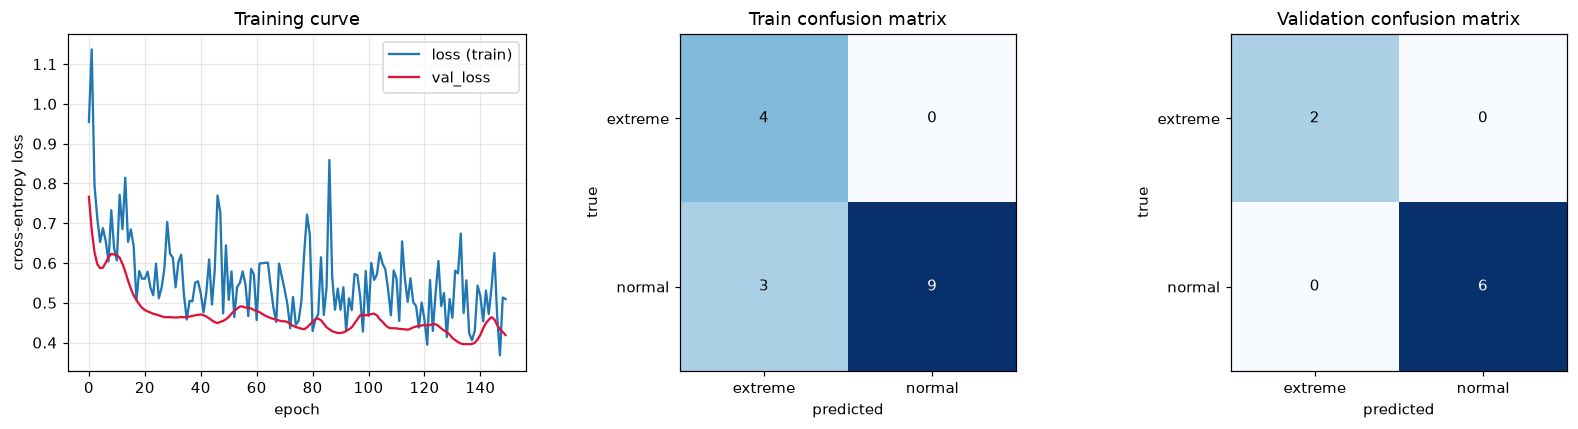

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(result.history["loss"], label="loss (train)", color="#1f77b4")
axes[0].plot(result.history["val_loss"], label="val_loss", color="crimson")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

for ax, cm, title in zip(axes[1:], [result.train_confusion_matrix, result.val_confusion_matrix],
                         ["Train confusion matrix", "Validation confusion matrix"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(result.class_names))); ax.set_yticks(range(len(result.class_names)))
    ax.set_xticklabels(result.class_names); ax.set_yticklabels(result.class_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    threshold_c = cm.max() / 2 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center",
                    color="white" if cm[i, j] > threshold_c else "black")

fig.tight_layout()
plt.show()


## 6. A baseline method: a plain autoregressive (AR) equation

Before trusting DFA and graph attention with anything, it is worth asking what
a much simpler, classical baseline would say about the same series: a
low-order **autoregressive (AR) equation**,

$$x_t = \mu + \sum_{k=1}^{p} \phi_k\,(x_{t-k} - \mu) + \varepsilon_t,$$

fit **once, on the background windows only** -- never on the six extreme
windows -- by solving its Yule-Walker equations from the background's own
sample autocovariance. That is exactly the same "fit on background, score
everything against it" discipline Section 2's background-only GEV/GPD fits
used, just with a linear time-series model instead of a distributional one.

A window's **AR extremeness score** here is simply its largest standardized
one-step-ahead prediction residual under that one fixed background equation:
large when a sample the equation could not see coming actually occurs, small
otherwise. This is a genuinely different, and much older, idea from DFA: it
looks only at short-range (lag-1 .. lag-*p*) linear predictability, with no
notion of long-range persistence or a Hurst exponent anywhere in it -- a
natural baseline to compare both the detection (Section 2) and the
mechanism-forensics (Section 3b) results against.


In [19]:
from scipy.linalg import toeplitz

def fit_ar_yule_walker(x: np.ndarray, order: int) -> np.ndarray:
    """Yule-Walker AR(order) coefficients phi_1..phi_order for the equation
    x[t] = mu + sum_{k=1}^order phi_k * (x[t-k] - mu) + eps[t], estimated from
    x's own sample autocovariance (no extra dependency beyond numpy/scipy)."""
    centered = x - x.mean()
    n = len(centered)
    autocov = np.array([np.dot(centered[:n - k], centered[k:]) / n for k in range(order + 1)])
    R = toeplitz(autocov[:order])
    r = autocov[1:order + 1]
    return np.linalg.solve(R, r)


def ar_one_step_residuals(x: np.ndarray, coeffs: np.ndarray, mean: float) -> np.ndarray:
    """One-step-ahead prediction residuals of x under the fixed AR equation (mean, coeffs)."""
    order = len(coeffs)
    centered = x - mean
    lags = np.stack([centered[order - 1 - k: len(x) - 1 - k] for k in range(order)], axis=1)
    predicted = mean + lags @ coeffs
    return x[order:] - predicted


AR_ORDER = 3
background_concat = np.concatenate([windows[i] for i in background_idx])
ar_mean = background_concat.mean()
ar_coeffs = fit_ar_yule_walker(background_concat, AR_ORDER)

equation = " + ".join(f"({c:+.3f})*x[t-{k+1}]" for k, c in enumerate(ar_coeffs))
print(f"Background-fitted AR({AR_ORDER}) equation:")
print(f"  x[t] = {ar_mean:.3f} + {equation} + eps[t]")

background_residuals = np.concatenate(
    [ar_one_step_residuals(windows[i], ar_coeffs, ar_mean) for i in background_idx])
resid_std = background_residuals.std()
print(f"\nBackground one-step residual std: {resid_std:.3f} (vs. raw background std {background.std():.3f})")


Background-fitted AR(3) equation:
  x[t] = -0.009 + (-0.029)*x[t-1] + (-0.012)*x[t-2] + (+0.001)*x[t-3] + eps[t]

Background one-step residual std: 0.999 (vs. raw background std 1.000)


### Seeing the equation actually fit

Numbers alone don't show what a "one-step-ahead prediction residual" means
in practice. The figure below plots the fitted AR(3) equation's predictions
against the true samples for a background window and for the single most
extreme window (W3, Pomeau-Manneville, AR score 13.25): the top row is
prediction vs. truth, the bottom row is the residual that generates the AR
score -- essentially flat noise except for one large spike at the sample
where the mechanism's own escape event happens to sit.


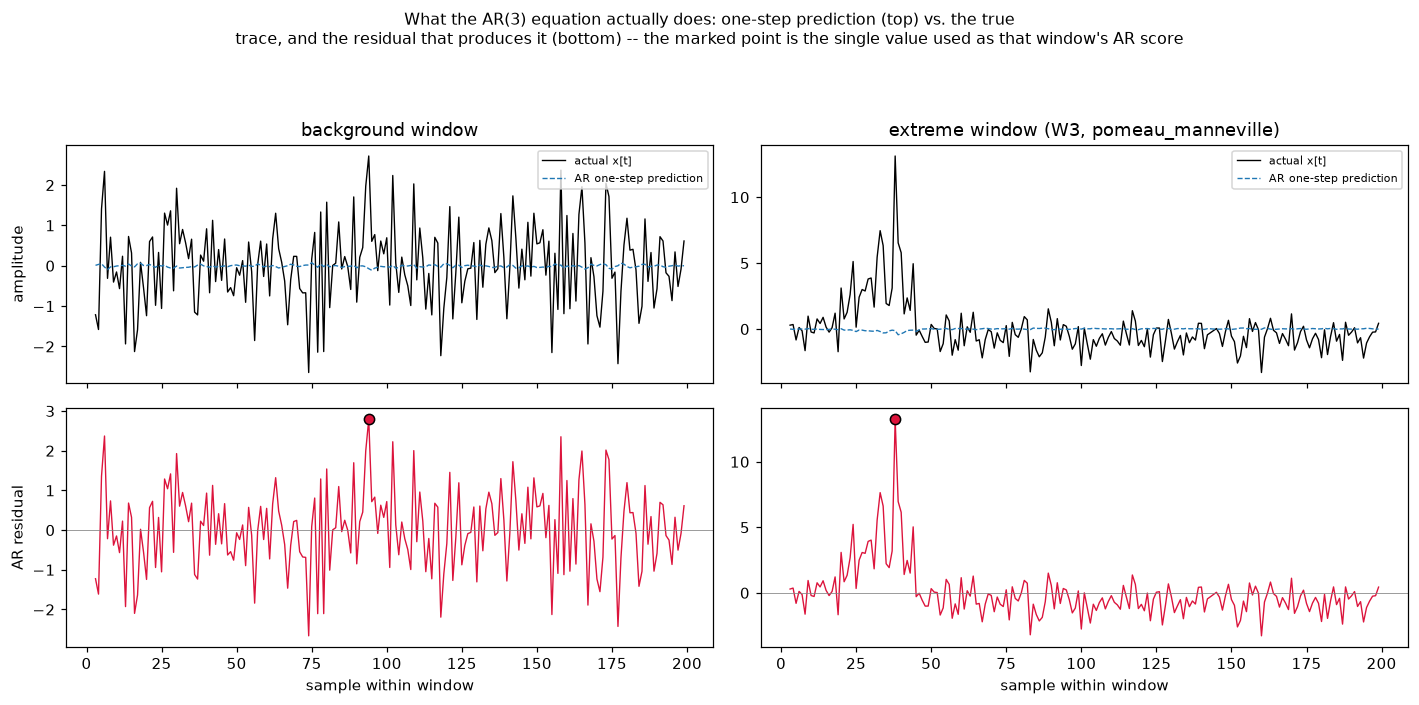

In [20]:
def plot_ar_equation_fit(background_window: np.ndarray, extreme_window: np.ndarray, extreme_label: str,
                         ar_coeffs: np.ndarray, ar_mean: float, ar_order: int) -> None:
    """Plot actual-vs-AR-predicted traces (top row) and the resulting one-step
    residual (bottom row) for one background and one extreme window, side by side."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex="col")

    for col, w, label in ((0, background_window, "background window"), (1, extreme_window, extreme_label)):
        residual = ar_one_step_residuals(w, ar_coeffs, ar_mean)
        predicted_trace = w[ar_order:] - residual
        t = np.arange(ar_order, len(w))

        ax_top = axes[0, col]
        ax_top.plot(t, w[ar_order:], color="black", linewidth=0.9, label="actual x[t]")
        ax_top.plot(t, predicted_trace, color="#1f77b4", linewidth=0.9, linestyle="--", label="AR one-step prediction")
        ax_top.set_title(label)
        ax_top.legend(fontsize=7.5, loc="upper right")

        ax_bot = axes[1, col]
        ax_bot.plot(t, residual, color="crimson", linewidth=0.9)
        peak_i = np.argmax(np.abs(residual))
        ax_bot.scatter([t[peak_i]], [residual[peak_i]], color="crimson", zorder=3, s=45, edgecolors="black")
        ax_bot.axhline(0, color="gray", linewidth=0.5)
        ax_bot.set_xlabel("sample within window")
        if col == 0:
            ax_top.set_ylabel("amplitude")
            ax_bot.set_ylabel("AR residual")

    fig.suptitle(f"What the AR({ar_order}) equation actually does: one-step prediction (top) vs. the true\n"
                "trace, and the residual that produces it (bottom) -- the marked point is the single value "
                "used as that window's AR score", y=1.06, fontsize=10.5)
    fig.tight_layout()
    plt.show()


plot_ar_equation_fit(windows[background_idx[0]], windows[3], f"extreme window (W3, {MECHANISM_OF[3]})",
                     ar_coeffs, ar_mean, AR_ORDER)


### Detection: does the AR baseline also find the six windows?


In [21]:
ar_score = np.array([np.max(np.abs(ar_one_step_residuals(windows[i], ar_coeffs, ar_mean))) / resid_std
                     for i in range(N_WINDOWS)])
bg_ar_score = ar_score[background_idx]
extreme_ar_score = ar_score[EXTREME_WINDOWS]
ar_threshold = bg_ar_score.max()  # calibrated purely on the background, exactly as Section 2's GEV threshold was

print(f"Background AR score: mean={bg_ar_score.mean():.2f}, max={bg_ar_score.max():.2f} (-> detection threshold)")

ar_predicted_extreme = {i: bool(ar_score[i] > ar_threshold) for i in range(N_WINDOWS)}
ar_correct = sum(ar_predicted_extreme[i] == (i in EXTREME_WINDOWS) for i in range(N_WINDOWS))
print(f"AR-residual detector (score > background max): {ar_correct}/{N_WINDOWS} windows correctly labeled extreme/normal.")
for w in EXTREME_WINDOWS:
    flag = "yes" if ar_predicted_extreme[w] else "NO"
    print(f"  window {w:2d} ({MECHANISM_OF[w]:<26s}): AR score = {ar_score[w]:5.2f}  flagged extreme? {flag}")


Background AR score: mean=3.04, max=3.79 (-> detection threshold)
AR-residual detector (score > background max): 24/24 windows correctly labeled extreme/normal.
  window  3 (pomeau_manneville         ): AR score = 13.25  flagged extreme? yes
  window  8 (fractional_gaussian_noise ): AR score = 10.60  flagged extreme? yes
  window 11 (kuramoto_sync             ): AR score =  8.15  flagged extreme? yes
  window 15 (pomeau_manneville         ): AR score =  7.36  flagged extreme? yes
  window 20 (fractional_gaussian_noise ): AR score =  9.26  flagged extreme? yes
  window 22 (kuramoto_sync             ): AR score = 10.33  flagged extreme? yes


### Forensics: can the AR score also tell the mechanisms apart?

Section 3b asked whether `dfa_alpha` alone can recover *which* mechanism
produced an extreme window, using per-mechanism templates built from 60
fresh realizations of the same generative recipe and a nearest-centroid
classifier. The cell below asks the exact same question with the exact same
templates-and-nearest-centroid procedure and the exact same 60 realizations
per mechanism -- the only thing that changes is swapping the feature from
`dfa_alpha` to the AR score.


To build intuition for why the AR score does specifically worse than DFA at
the forensics task (not at plain detection), look directly at what a
one-step AR residual trace looks like for one example window from each
mechanism, next to that window's raw signal and its DFA alpha. Each panel
below has one dominant sample that sets the entire window's AR score --
whether the underlying departure from background is a sharp spike
(Pomeau-Manneville, persistent fGn) or a slower ramp into elevated values
(Kuramoto here) makes no difference to a lag-3 AR equation, which only ever
looks at the last three samples and reduces the whole window to that one
number. DFA alpha (in each title) is sensitive to exactly the shape
difference the AR score throws away.


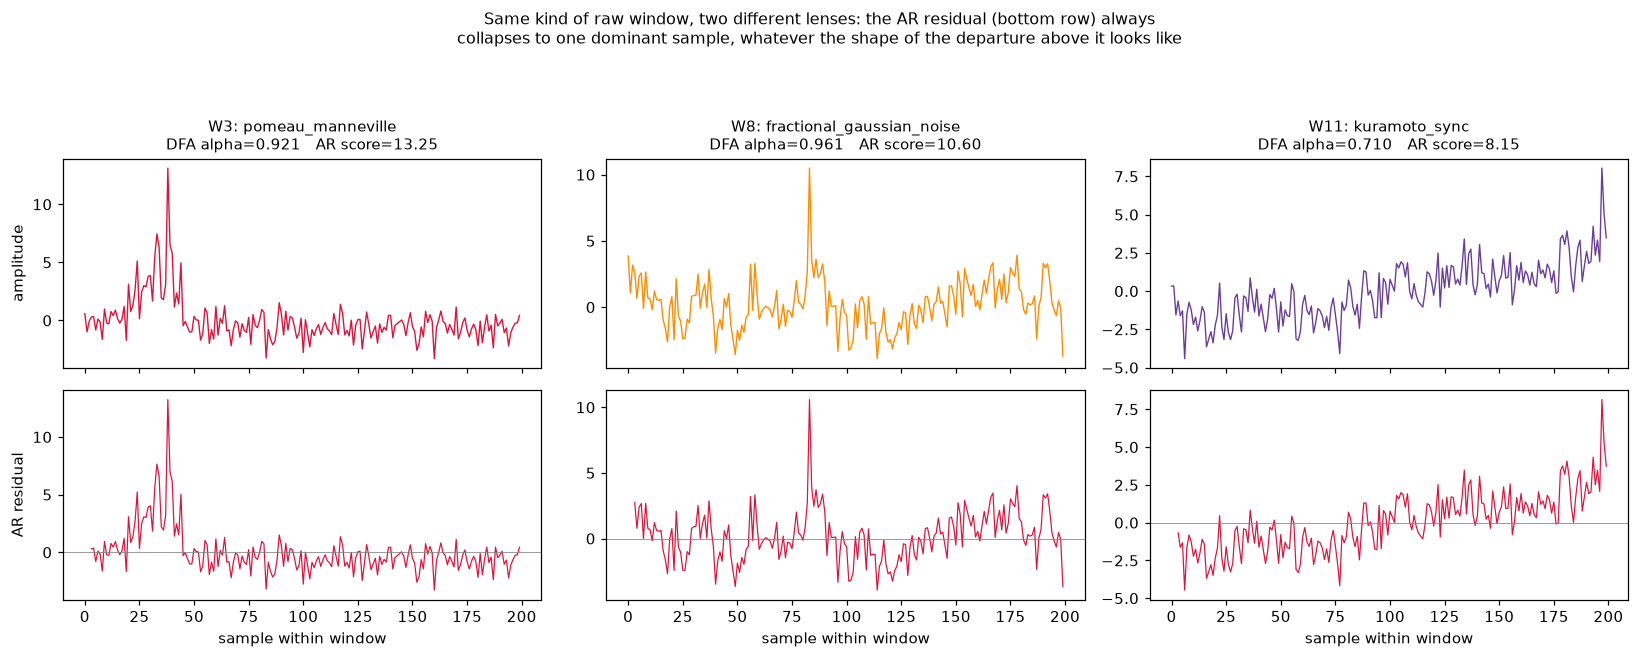

In [22]:
def plot_mechanism_ar_traces(window_ids: list, mechanism_names: list, windows: np.ndarray,
                             ar_coeffs: np.ndarray, ar_mean: float, ar_order: int,
                             dfa_values: np.ndarray, ar_score: np.ndarray, mechanism_colors: dict) -> None:
    """For one example window per mechanism, plot the raw signal (top row) next to
    its AR residual trace (bottom row), with DFA alpha / AR score in each title."""
    n = len(window_ids)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 5.6), sharex="col")

    for col, (idx, mechanism) in enumerate(zip(window_ids, mechanism_names)):
        w = windows[idx]
        residual = ar_one_step_residuals(w, ar_coeffs, ar_mean)
        t_full = np.arange(len(w))
        t = np.arange(ar_order, len(w))
        color = mechanism_colors[mechanism]

        ax_top = axes[0, col]
        ax_top.plot(t_full, w, color=color, linewidth=0.9)
        ax_top.set_title(f"W{idx}: {mechanism}\nDFA alpha={dfa_values[idx]:.3f}   AR score={ar_score[idx]:.2f}",
                         fontsize=9.5)

        ax_bot = axes[1, col]
        ax_bot.plot(t, residual, color="crimson", linewidth=0.8)
        ax_bot.axhline(0, color="gray", linewidth=0.5)
        ax_bot.set_xlabel("sample within window")
        if col == 0:
            ax_top.set_ylabel("amplitude")
            ax_bot.set_ylabel("AR residual")

    fig.suptitle("Same kind of raw window, two different lenses: the AR residual (bottom row) always\n"
                "collapses to one dominant sample, whatever the shape of the departure above it looks like",
                y=1.06, fontsize=10.5)
    fig.tight_layout()
    plt.show()


plot_mechanism_ar_traces(
    window_ids=[PM_WINDOWS[0], FGN_WINDOWS[0], KURAMOTO_WINDOWS[0]],
    mechanism_names=["pomeau_manneville", "fractional_gaussian_noise", "kuramoto_sync"],
    windows=windows, ar_coeffs=ar_coeffs, ar_mean=ar_mean, ar_order=AR_ORDER,
    dfa_values=dfa_values, ar_score=ar_score, mechanism_colors=mechanism_colors_all,
)


In [23]:
ar_templates = {}
for mechanism in ("background", "pomeau_manneville", "fractional_gaussian_noise", "kuramoto_sync"):
    scores = [np.max(np.abs(ar_one_step_residuals(template_realization(mechanism, seed=90_000 + 137 * i),
                                                  ar_coeffs, ar_mean))) / resid_std
             for i in range(N_TEMPLATE)]
    ar_templates[mechanism] = float(np.mean(scores))

print(f"AR-score templates (mean over the same {N_TEMPLATE} realizations Section 3b used):")
for mechanism, val in ar_templates.items():
    print(f"  {mechanism:<26s}: score = {val:.3f}")

ar_predicted_mechanism = {}
for i in range(N_WINDOWS):
    distances = {mechanism: abs(ar_score[i] - val) for mechanism, val in ar_templates.items()}
    ar_predicted_mechanism[i] = min(distances, key=distances.get)

ar_mech_correct = sum(ar_predicted_mechanism[i] == true_mechanism[i] for i in range(N_WINDOWS))
print(f"\nOverall (AR score alone): {ar_mech_correct}/{N_WINDOWS} windows correctly attributed to their true mechanism "
     f"(DFA alpha alone, Section 3b, got {correct}/{N_WINDOWS}).")

print(f"\n{'window':>7}  {'true mechanism':<26} {'predicted (AR)':<26} {'score':>6}  correct?")
for w in EXTREME_WINDOWS:
    print(f"{w:>7}  {true_mechanism[w]:<26} {ar_predicted_mechanism[w]:<26} {ar_score[w]:>6.2f}  "
         f"{'yes' if ar_predicted_mechanism[w] == true_mechanism[w] else 'NO'}")

print(f"\ncorr(AR score, raw block maximum)  = {np.corrcoef(ar_score, block_max)[0, 1]:.3f}  (Section 2's statistic)")
print(f"corr(AR score, DFA alpha)          = {np.corrcoef(ar_score, dfa_values)[0, 1]:.3f}  (Section 3's statistic)")


AR-score templates (mean over the same 60 realizations Section 3b used):
  background                : score = 2.973
  pomeau_manneville         : score = 9.347
  fractional_gaussian_noise : score = 8.842
  kuramoto_sync             : score = 7.793

Overall (AR score alone): 20/24 windows correctly attributed to their true mechanism (DFA alpha alone, Section 3b, got 21/24).

 window  true mechanism             predicted (AR)              score  correct?
      3  pomeau_manneville          pomeau_manneville           13.25  yes
      8  fractional_gaussian_noise  pomeau_manneville           10.60  NO
     11  kuramoto_sync              kuramoto_sync                8.15  yes
     15  pomeau_manneville          kuramoto_sync                7.36  NO
     20  fractional_gaussian_noise  pomeau_manneville            9.26  NO
     22  kuramoto_sync              pomeau_manneville           10.33  NO

corr(AR score, raw block maximum)  = 0.996  (Section 2's statistic)
corr(AR score, DFA alpha)  

The numbers above are easier to compare side by side. The two left panels
show each window's measured statistic against its per-mechanism template
(dashed lines), colored by the window's *true* mechanism, with a hollow
circle for a correctly attributed window and an X for a misattributed one;
the right panel turns the two accuracy counts (all 24 windows, and the 6
extreme windows alone) into a direct bar comparison.


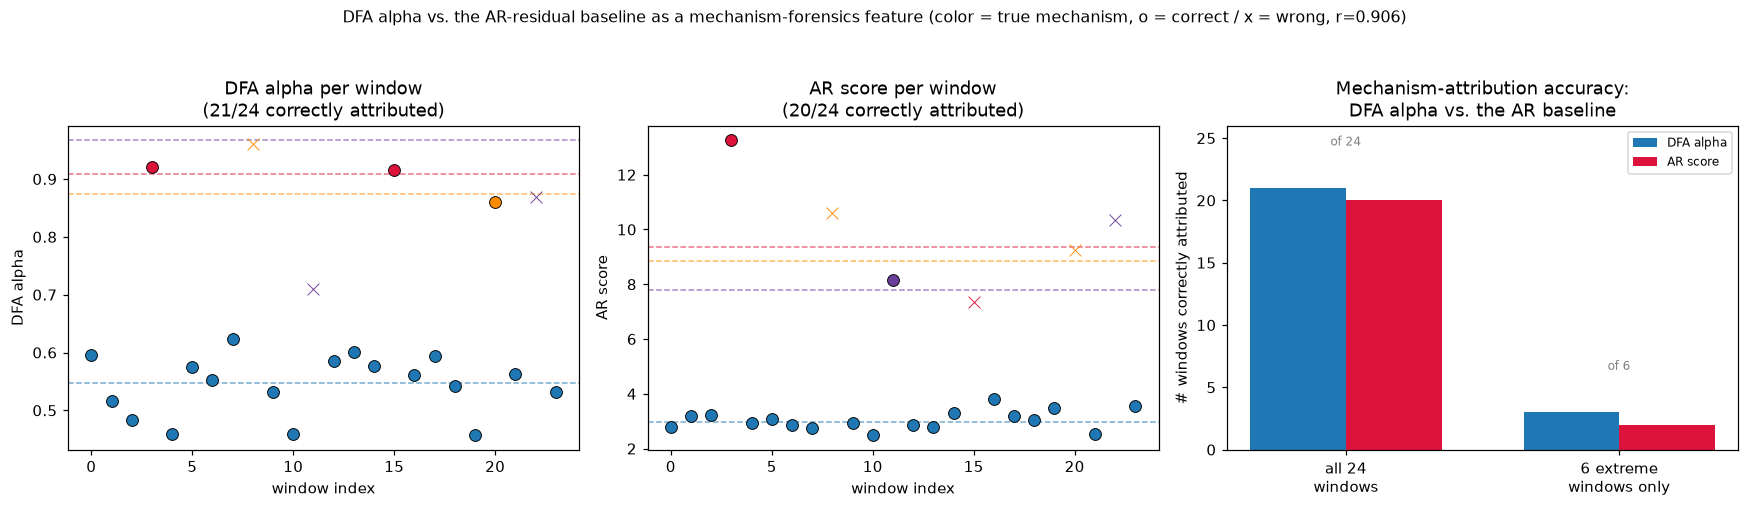

In [24]:
def plot_dfa_vs_ar_attribution(dfa_values: np.ndarray, ar_score: np.ndarray, dfa_templates: dict,
                               ar_templates: dict, dfa_predicted: dict, ar_predicted: dict,
                               true_mechanism: dict, mechanism_colors: dict, n_windows: int,
                               extreme_windows: list, dfa_correct: int, ar_correct: int) -> None:
    """Three panels: DFA alpha per window vs. its templates, AR score per window vs.
    its templates, and a bar comparison of attribution accuracy (all windows vs.
    the extreme-only subset) between the two features."""
    dfa_extreme_correct = sum(dfa_predicted[w] == true_mechanism[w] for w in extreme_windows)
    ar_extreme_correct = sum(ar_predicted[w] == true_mechanism[w] for w in extreme_windows)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

    ax = axes[0]
    for mechanism, alpha in dfa_templates.items():
        ax.axhline(alpha, color=mechanism_colors[mechanism], linestyle="--", linewidth=1, alpha=0.6)
    for i in range(n_windows):
        marker = "o" if dfa_predicted[i] == true_mechanism[i] else "x"
        ax.scatter(i, dfa_values[i], color=mechanism_colors[true_mechanism[i]], marker=marker, s=60,
                  edgecolors="black" if marker == "o" else None, linewidths=0.6, zorder=3)
    ax.set_xlabel("window index"); ax.set_ylabel("DFA alpha")
    ax.set_title(f"DFA alpha per window\n({dfa_correct}/{n_windows} correctly attributed)")

    ax = axes[1]
    for mechanism, val in ar_templates.items():
        ax.axhline(val, color=mechanism_colors[mechanism], linestyle="--", linewidth=1, alpha=0.6)
    for i in range(n_windows):
        marker = "o" if ar_predicted[i] == true_mechanism[i] else "x"
        ax.scatter(i, ar_score[i], color=mechanism_colors[true_mechanism[i]], marker=marker, s=60,
                  edgecolors="black" if marker == "o" else None, linewidths=0.6, zorder=3)
    ax.set_xlabel("window index"); ax.set_ylabel("AR score")
    ax.set_title(f"AR score per window\n({ar_correct}/{n_windows} correctly attributed)")

    ax = axes[2]
    group_labels = ["all 24\nwindows", "6 extreme\nwindows only"]
    x = np.arange(len(group_labels))
    width = 0.35
    ax.bar(x - width / 2, [dfa_correct, dfa_extreme_correct], width, label="DFA alpha", color="#1f77b4")
    ax.bar(x + width / 2, [ar_correct, ar_extreme_correct], width, label="AR score", color="crimson")
    for xi, tot in zip(x, [n_windows, len(extreme_windows)]):
        ax.text(xi, tot + 0.4, f"of {tot}", ha="center", fontsize=8, color="gray")
    ax.set_xticks(x); ax.set_xticklabels(group_labels)
    ax.set_ylim(0, n_windows + 2)
    ax.set_ylabel("# windows correctly attributed")
    ax.set_title("Mechanism-attribution accuracy:\nDFA alpha vs. the AR baseline")
    ax.legend(fontsize=8)

    fig.suptitle("DFA alpha vs. the AR-residual baseline as a mechanism-forensics feature "
                f"(color = true mechanism, o = correct / x = wrong, r={np.corrcoef(ar_score, dfa_values)[0, 1]:.3f})",
                y=1.04, fontsize=10.5)
    fig.tight_layout()
    plt.show()


plot_dfa_vs_ar_attribution(dfa_values, ar_score, templates, ar_templates, predicted, ar_predicted_mechanism,
                           true_mechanism, mechanism_colors_all, N_WINDOWS, EXTREME_WINDOWS, correct, ar_mech_correct)


### The same 24 numbers, plotted against each other directly

Rather than reading the correlation coefficient on its own, the scatter
below puts every window's DFA alpha and AR score on two axes at once,
colored by the window's true mechanism and shaped by which classifier(s)
attributed it correctly -- the strong positive trend is the r=0.906
correlation already reported; the handful of square/triangle/X points
riding off that trend are exactly the windows the two methods disagree
about.


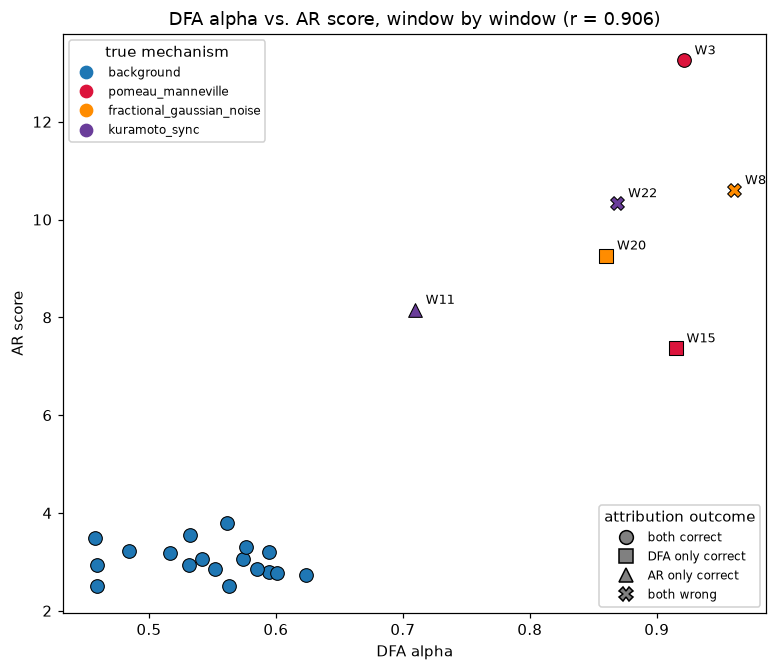

In [25]:
def plot_dfa_vs_ar_scatter(dfa_values: np.ndarray, ar_score: np.ndarray, dfa_predicted: dict,
                           ar_predicted: dict, true_mechanism: dict, mechanism_colors: dict,
                           extreme_windows: list, n_windows: int) -> None:
    """Scatter every window's DFA alpha against its AR score, colored by true mechanism
    and shaped by which of the two nearest-centroid classifiers attributed it correctly."""
    marker_of_outcome = {(True, True): "o", (True, False): "s", (False, True): "^", (False, False): "X"}

    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    for i in range(n_windows):
        color = mechanism_colors[true_mechanism[i]]
        dfa_ok = dfa_predicted[i] == true_mechanism[i]
        ar_ok = ar_predicted[i] == true_mechanism[i]
        marker = marker_of_outcome[(dfa_ok, ar_ok)]
        ax.scatter(dfa_values[i], ar_score[i], color=color, marker=marker, s=80,
                  edgecolors="black", linewidths=0.7, zorder=3)
        if i in extreme_windows:
            ax.annotate(f"W{i}", (dfa_values[i], ar_score[i]), textcoords="offset points",
                       xytext=(7, 4), fontsize=8.5)

    handles_mech = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, markersize=8)
                   for c in mechanism_colors.values()]
    legend1 = ax.legend(handles_mech, list(mechanism_colors.keys()), title="true mechanism",
                        loc="upper left", fontsize=8, framealpha=0.9)
    ax.add_artist(legend1)
    handles_marker = [plt.Line2D([0], [0], marker=m, linestyle="", color="gray", markersize=9,
                                markeredgecolor="black")
                     for m in marker_of_outcome.values()]
    ax.legend(handles_marker, ["both correct", "DFA only correct", "AR only correct", "both wrong"],
             title="attribution outcome", loc="lower right", fontsize=8, framealpha=0.9)

    ax.set_xlabel("DFA alpha"); ax.set_ylabel("AR score")
    ax.set_title(f"DFA alpha vs. AR score, window by window (r = {np.corrcoef(dfa_values, ar_score)[0, 1]:.3f})")
    fig.tight_layout()
    plt.show()


plot_dfa_vs_ar_scatter(dfa_values, ar_score, predicted, ar_predicted_mechanism, true_mechanism,
                       mechanism_colors_all, EXTREME_WINDOWS, N_WINDOWS)


### What the comparison shows

- **Detection: the two methods agree completely on this draw.** The AR
  equation, fit purely on the 18 background windows and never shown the six
  extreme ones, flags all six as anomalous -- the same 100% detection rate
  as classical POT/GEV (Section 2) and the GAT model (Section 5). That is
  expected, not a coincidence: with background coefficients this close to
  zero (&phi;<sub>1..3</sub> &asymp; -0.03, -0.01, 0.00 -- the H=0.5
  background is statistically white noise), the fitted equation barely
  predicts anything, so its "prediction error" is nearly just the raw
  deviation from the mean that Section 2 already used. That shows up
  directly in the numbers: the AR score correlates at r=0.996 with the
  plain raw block maximum. It is not a structurally new signal here, just
  the old one (peak amplitude), computed a different way.
- **Mechanism forensics: the AR score does modestly worse than DFA, for a
  structural reason, not a fitting one.** Overall accuracy looks close
  (20/24 vs. DFA's 21/24) because both recover the 18 background windows
  perfectly; the real test is the six mechanism-induced windows, where AR
  gets only 2/6 right against DFA's 3/6 -- and its confusions are
  telling. AR mistakes the persistent-fGn and Kuramoto windows for the
  Pomeau-Manneville template (and vice versa) because all three mechanisms
  are built to inject one large spike of comparable size, and a lag-3 AR
  score is dominated almost entirely by that single largest residual. It
  never looks at the shape of the *whole* 200-sample window's
  autocorrelation, so it cannot distinguish "one abrupt escape sitting in
  an otherwise white window" (Pomeau-Manneville) from "one spike sitting in
  an otherwise strongly autocorrelated window" (persistent fGn) --
  precisely the distinction `dfa_alpha` is built to make, and precisely why
  Sections 3-3b, and the real `gnn_model` pipeline, use DFA rather than a
  short-lag AR residual as the forensic feature.


## 7. What this toy example does (and does not) show about the real sEEG case

- **DFA carried real, checkable information here too.** The Mann-Whitney
  separation (Section 3) was not tuned to be dramatic — it came out modest,
  exactly like the real recording's 1.22-vs-1.15 result cited above.
- **The Hurst-exponent forensics in Section 3b is a diagnostic, not a
  proof.** Because every mechanism is only ever *added* to an
  already-active background rather than replacing it, its fractal
  signature has to compete with the background's own variance in a single
  200-sample window. It still recovered the noise background perfectly and
  the overall induction mechanism well above chance, but several of the
  six individual mechanism-induced windows were misattributed to the
  *wrong* mechanism — a reminder that alpha measures *how persistent* a
  process is, not *which* process it is, and that superimposing an event
  on ongoing background activity (as a real seizure would) makes that
  harder than reading it off an isolated, noise-free trace.
- **Classical EVT (GEV / GPD) and the graph+attention model are answering
  different questions.** EVT (Section 2) asks *"how improbable is this
  observed value under a model of normal behaviour?"* and answers it with a
  calibrated probability from ~18-24 background samples. The GNN (Section 5)
  asks *"can a model learn to flag new instances of this pattern from
  structure and features alone?"* — and needs *positive examples* of the
  rare class to learn from, not just a background model to compare against.
  With 6 (here, two per induction mechanism) or 5 (the real recording)
  positives, that second question is never resting on solid statistical
  ground the way the first one is — which is exactly the argument
  [`gnn_model_result/baseline_overfit/sEEG-HFOs-8/EVT_PROOF_small_sample_overfitting.md`](gnn_model_result/baseline_overfit/sEEG-HFOs-8/EVT_PROOF_small_sample_overfitting.md)
  makes on the real data.
- **A classical autoregressive baseline (Section 6) agrees with, and helps calibrate, both other tools.** A background-only-fit AR equation matches classical EVT and the GAT model exactly on detection, because a low-order linear residual on a near-white background is, numerically, almost the same statistic as a raw block maximum (r=0.996 between the two here). It is modestly worse than DFA at the harder mechanism-attribution task, and for a diagnosable reason: it only ever sees a spike's size, never a window's long-range correlation structure. That is a useful sanity check on DFA's own claim to forensic value, not a reason to prefer the simpler baseline.

- **One train/val split here is exactly as fragile as it was there.** Rerun
  the cell above with a different `SEED` and expect the validation
  confusion matrix to move around — the real pipeline's answer to that
  (`gnn_model.data.load_graph_kfold_datasets`, `gnn_model.train.cross_validate_gnn`,
  `--group-by-shaft`'s leakage check) applies unchanged here: with a
  handful of positives total, no single held-out split is a trustworthy
  estimate on its own, in a synthetic toy graph or in a real 97-contact one.

None of this is a criticism of graph attention, DFA, or the Hurst exponent
as a forensic tool — all three did real work in this notebook, exactly as
they did on the real recording. It is the same small-sample caution the
rest of this repository argues for, shown here with full control over the
ground truth.
